In [11]:
import pandas as pd
import numpy as np
import sqlite3
from sklearn.model_selection import train_test_split

con = sqlite3.connect('../database/bank_churn.db')
df = pd.read_sql("SELECT * FROM bank_customers", con)
con.close()



# --- FEATURE ENGINEERING ---
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
current_year = 2025 
df['age'] = current_year - df['date_of_birth'].dt.year
df['tenure_to_age'] = df['customer_tenure'] / df['age']
df['products_per_year'] = df['numofproducts'] / (df['customer_tenure'].replace(0, 1))

cols_to_drop = [
    'rownumber', 'customerid', 'surname', 'first_name',
    'address', 'contact_information', 'date_of_birth',
    'churn_reason', 'churn_date', 'occupation', 'balance'
]

df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Size before cleaning: {df.shape[1]}")
print(f"Size after cleaning: {df_clean.shape[1]}")

df_clean.head()

Size before cleaning: 28
Size after cleaning: 17


,gender,marital_status,number_of_dependents,income,education_level,customer_tenure,customer_segment,preferred_communication_channel,credit_score,credit_history_length,outstanding_loans,churn_flag,numofproducts,numcomplaints,age,tenure_to_age,products_per_year
0,Male,Divorced,3,77710.14,High School,30,Retail,Phone,397,24,41959.74,0,1,0,38,0.789474,0.033333
1,Female,Married,1,58209.87,High School,27,SME,Email,665,10,8916.67,0,4,1,25,1.080000,0.148148
2,Female,Single,1,9794.01,High School,14,Retail,Email,715,21,43270.54,0,2,6,71,0.197183,0.142857
3,Female,Divorced,5,15088.98,High School,23,Corporate,Phone,747,17,17887.65,0,1,0,34,0.676471,0.043478
4,Female,Divorced,2,60726.56,Master's,22,Corporate,Email,549,25,32686.84,0,5,6,33,0.666667,0.227273


In [12]:
import pickle
metadata = {}

input_num_cols = ['number_of_dependents', 'income', 'customer_tenure', 'credit_score', 
                  'credit_history_length', 'outstanding_loans', 'churn_flag', 'numofproducts',
                  'numcomplaints', 'age']
for col in input_num_cols:
    metadata[col] = {
        'min': float(df[col].min()),
        'max': float(df[col].max()),
        'default': float(df[col].median())
    }

input_cat_cols = ['gender', 'marital_status', 'education_level', 
                  'customer_segment', 'preferred_communication_channel']

for col in input_cat_cols:
    unique_vals = sorted(df[col].unique().tolist())
    metadata[col] = unique_vals

print(f"Metadata: {metadata}")

with open ('../data/processed/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

Metadata: {'number_of_dependents': {'min': 0.0, 'max': 5.0, 'default': 3.0}, 'income': {'min': 5000.96, 'max': 99999.51, 'default': 52658.11}, 'customer_tenure': {'min': 1.0, 'max': 30.0, 'default': 15.0}, 'credit_score': {'min': 300.0, 'max': 850.0, 'default': 574.0}, 'credit_history_length': {'min': 1.0, 'max': 30.0, 'default': 16.0}, 'outstanding_loans': {'min': 1000.43, 'max': 49999.69, 'default': 25505.285}, 'churn_flag': {'min': 0.0, 'max': 1.0, 'default': 0.0}, 'numofproducts': {'min': 1.0, 'max': 5.0, 'default': 3.0}, 'numcomplaints': {'min': 0.0, 'max': 10.0, 'default': 5.0}, 'age': {'min': 19.0, 'max': 77.0, 'default': 48.0}, 'gender': ['Female', 'Male'], 'marital_status': ['Divorced', 'Married', 'Single'], 'education_level': ["Bachelor's", 'Diploma', 'High School', "Master's"], 'customer_segment': ['Corporate', 'Retail', 'SME'], 'preferred_communication_channel': ['Email', 'Phone']}


In [13]:
X = df_clean.drop(columns=['churn_flag'])
y = df_clean['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (92512, 16)
Test shape: (23128, 16)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Data was successfully transformed!")
X_train_prep.head()

Numerical columns: ['number_of_dependents', 'income', 'customer_tenure', 'credit_score', 'credit_history_length', 'outstanding_loans', 'numofproducts', 'numcomplaints', 'tenure_to_age', 'products_per_year']
Categorical columns: ['gender', 'marital_status', 'education_level', 'customer_segment', 'preferred_communication_channel']
Data was successfully transformed!


,number_of_dependents,income,customer_tenure,credit_score,credit_history_length,outstanding_loans,numofproducts,numcomplaints,tenure_to_age,products_per_year,...,marital_status_Single,education_level_Bachelor's,education_level_Diploma,education_level_High School,education_level_Master's,customer_segment_Corporate,customer_segment_Retail,customer_segment_SME,preferred_communication_channel_Email,preferred_communication_channel_Phone
16758,0.875285,0.894357,-0.747594,1.099414,0.053986,0.768380,-0.708177,-0.947944,-0.909172,-0.270888,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
26845,0.875285,0.843119,-1.556051,-1.339323,-0.061629,1.124395,-0.708177,-1.264690,-1.159995,0.893318,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
34033,-1.467638,1.590272,-0.863087,-1.194759,-1.333399,1.118898,0.708912,0.952532,-0.697125,0.144900,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
101171,-0.881907,1.682532,1.677780,-1.169617,1.094525,-0.093809,-1.416721,0.635786,0.455600,-0.553623,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
103733,1.461015,-0.403573,-0.516606,-1.490173,0.053986,0.179521,0.000368,-0.947944,-0.333995,-0.195290,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [15]:
import pickle

with open('../data/processed/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

In [16]:
object_cols = X_train.select_dtypes(include=['object']).columns
print(X_train[object_cols].nunique().sort_values(ascending=False))

education_level                    4
customer_segment                   3
marital_status                     3
gender                             2
preferred_communication_channel    2
dtype: int64


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
print("Before SMOTE")
print(y_train.value_counts())

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_prep, y_train)

print("After SMOTE")
print(y_train_resampled.value_counts())

print(f"New shape of X_train: {X_train_resampled.shape}")

Before SMOTE
churn_flag
0    81237
1    11275
Name: count, dtype: int64
After SMOTE
churn_flag
0    81237
1    81237
Name: count, dtype: int64
New shape of X_train: (162474, 24)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_resampled, y_train_resampled)
y_pred = log_reg.predict(X_test_prep)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.71      0.81     20309
           1       0.25      0.72      0.37      2819

    accuracy                           0.71     23128
   macro avg       0.60      0.71      0.59     23128
weighted avg       0.86      0.71      0.76     23128



                                  Feature  Importance  Abs importance
7                           numcomplaints    0.922116        0.922116
3                            credit_score   -0.831536        0.831536
6                           numofproducts   -0.798032        0.798032
23  preferred_communication_channel_Phone   -0.118883        0.118883
10                          gender_Female   -0.112687        0.112687
11                            gender_Male   -0.100945        0.100945
22  preferred_communication_channel_Email   -0.094749        0.094749
13                 marital_status_Married   -0.083155        0.083155
20                customer_segment_Retail   -0.082318        0.082318
19             customer_segment_Corporate   -0.081220        0.081220


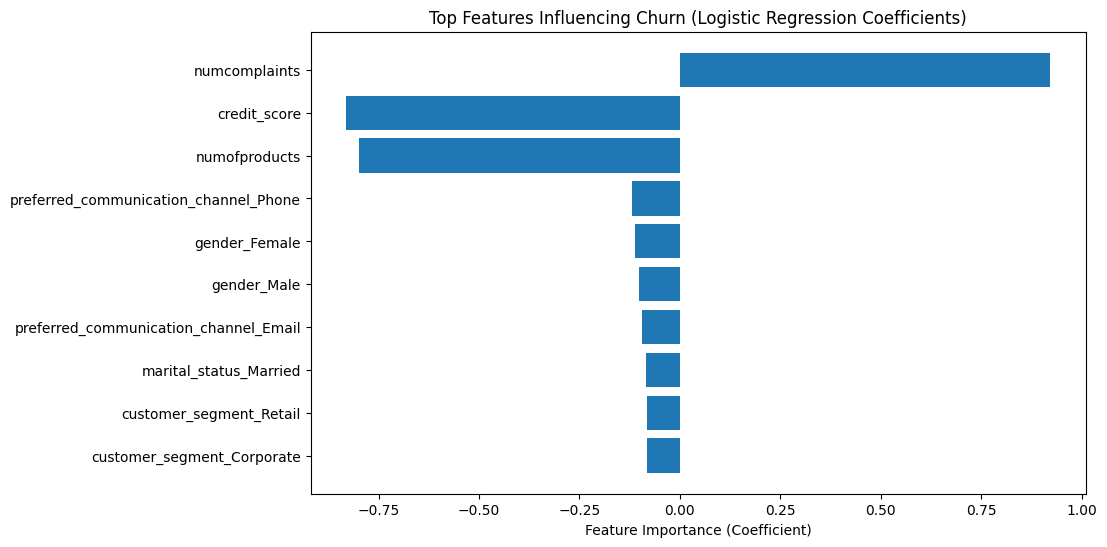

In [19]:
import matplotlib.pyplot as plt
feature_names = X_train_resampled.columns
coefficients = log_reg.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

feature_importance['Abs importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs importance', ascending=False)
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(10), feature_importance['Importance'].head(10))
plt.title("Top Features Influencing Churn (Logistic Regression Coefficients)")
plt.xlabel("Feature Importance (Coefficient)")
plt.gca().invert_yaxis() 
plt.show()


In [20]:
import pickle
import os

os.makedirs('../data/processed', exist_ok=True)

data_to_save = {
    "X_train_resampled": X_train_resampled,
    "y_train_resampled": y_train_resampled,
    "X_test_prep": X_test_prep,
    "y_test": y_test,
    "y_train": y_train,
    "feature_names": X_train_prep.columns.tolist()
}

with open("../data/processed/churn_data.pkl", "wb") as f:
    pickle.dump(data_to_save, f)